In [2]:
%load_ext autoreload
%autoreload 1

import torch
import glob
import math
import PIL
import torchvision.transforms as transforms

from mylib.plot import plot_imgs

In [9]:
images_path = sorted(glob.glob(f"/home/mattia/Desktop/datasets/mipnerf360/bonsai/images/*"))[:5]

# load images
images = [PIL.Image.open(img_path) for img_path in images_path]
images_th = [transforms.ToTensor()(img).unsqueeze(0) for img in images]

# # resize to 518 long edge
min_size = int(images_th[0].shape[3] / (images_th[0].shape[2]/518))
resize_transform = transforms.Resize(min_size)
images_th = [resize_transform(img_th) for img_th in images_th]

# print sizes
for i, img_th in enumerate(images_th):
    print(f"Image {i}: {img_th.shape}")  # (1, 3, H, W)

Image 0: torch.Size([1, 3, 777, 1165])
Image 1: torch.Size([1, 3, 777, 1165])
Image 2: torch.Size([1, 3, 777, 1165])
Image 3: torch.Size([1, 3, 777, 1165])
Image 4: torch.Size([1, 3, 777, 1165])


In [11]:
from extractors.canny import CannyEdgeDetector
canny_extractor = CannyEdgeDetector()

from extractors.TEED.teed_wrapper import TeedWrapper
teed_extractor = TeedWrapper(device="cuda")

# from extractors.DiffusionEdge.diffusion_edge_wrapper import DiffusionEdgeDetector
# diffedge = DiffusionEdgeDetector(device="cuda")

from extractors.rcf_torch.rfc_wrapper import RCFWrapper
rcf_extractor = RCFWrapper(device="cuda")

CannyEdgeDetector initialized with low_threshold=0.2, high_threshold=0.25, hysteresis=True, kernel_size=7, sigma=2.0, device=cuda

Loaded RCF checkpoint from /home/mattia/Desktop/Repos/batchsfm/extractors/rcf_torch/bsds500_pascal_model.pth


In [12]:
k = 0
img_canny = canny_extractor(images_th[k]).squeeze().cpu()
img_teed = teed_extractor(images_th[k], low_threshold=0.95, high_threshold=1.0).squeeze().cpu()
# img_diffedge = diffedge(images_th[k], low_threshold=0.01, high_threshold=0.05).squeeze().cpu()
img_rcf = rcf_extractor(images[k], th=0.6667).squeeze().cpu()

# print non vers values
print(f"Canny: {torch.nonzero(img_canny).sum().item():,}")
print(f"TEED: {torch.nonzero(img_teed).sum().item():,}")
# print(f"DiffusionEdge: {torch.nonzero(img_diffedge).sum().item():,}")
print(f"RCF: {torch.nonzero(img_rcf).sum().item():,}")

Canny: 24,512,608
TEED: 9,665,116
RCF: 609,345,295


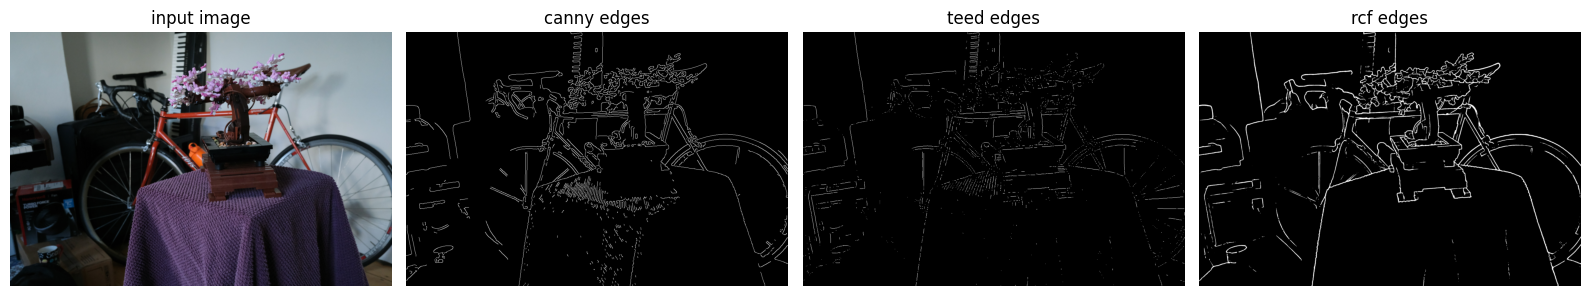

In [14]:
plot_imgs([
    images_th[k].squeeze().permute(1, 2, 0).cpu().numpy(), 
    img_canny, 
    img_teed,
    # img_diffedge
    img_rcf
    ], 
    titles=["input image", "canny edges", "teed edges", "rcf edges"], cmap=[None, "gray", "gray", "gray"],
    figsize=(16, 12)
)

In [ ]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

: 

In [ ]:
%timeit img_canny = canny_extractor(images_th[k]).squeeze().cpu()
%timeit img_teed = teed_extractor(images_th[k], low_threshold=0.8, high_threshold=1.0).squeeze().cpu()
%timeit img_diffedge = diffedge(images_th[k], low_threshold=0.01, high_threshold=0.05).squeeze().cpu()

The slowest run took 11.22 times longer than the fastest. This could mean that an intermediate result is being cached.
28.6 ms ± 23.5 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.53 ms ± 131 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
315 ms ± 53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
